In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

url = "https://raw.githubusercontent.com/alexeygrigorev/datasets/master/course_lead_scoring.csv"
df = pd.read_csv(url)

print(df.head())
print(df.isnull().sum())

    lead_source    industry  number_of_courses_viewed  annual_income  \
0      paid_ads         NaN                         1        79450.0   
1  social_media      retail                         1        46992.0   
2        events  healthcare                         5        78796.0   
3      paid_ads      retail                         2        83843.0   
4      referral   education                         3        85012.0   

  employment_status       location  interaction_count  lead_score  converted  
0        unemployed  south_america                  4        0.94          1  
1          employed  south_america                  1        0.80          0  
2        unemployed      australia                  3        0.69          1  
3               NaN      australia                  1        0.87          0  
4     self_employed         europe                  3        0.62          1  
lead_source                 128
industry                    134
number_of_courses_viewed     

In [2]:
cat_cols = df.select_dtypes(include=['object']).columns
df[cat_cols] = df[cat_cols].fillna('NA')

num_cols = df.select_dtypes(exclude=['object']).columns
df[num_cols] = df[num_cols].fillna(0.0)


In [3]:
df_full_train, df_test = train_test_split(df, test_size=0.2, random_state=1)
df_train, df_val = train_test_split(df_full_train, test_size=0.25, random_state=1)  # 0.25 of 0.8 = 0.2

print(len(df_train), len(df_val), len(df_test))


876 293 293


Question 1. ROC AUC feature importance

In [4]:
y_train = df_train['converted']

cols = ['lead_score', 'number_of_courses_viewed', 'interaction_count', 'annual_income']

for c in cols:
    scores = df_train[c]
    auc = roc_auc_score(y_train, scores)
    if auc < 0.5:
        auc = roc_auc_score(y_train, -scores)
    print(f"{c}: {auc:.3f}")


lead_score: 0.614
number_of_courses_viewed: 0.764
interaction_count: 0.738
annual_income: 0.552


In [6]:
from sklearn.feature_extraction import DictVectorizer
from sklearn.linear_model import LogisticRegression

y_train = df_train['converted'].values
y_val = df_val['converted'].values

X_train = df_train.drop('converted', axis=1)
X_val = df_val.drop('converted', axis=1)


In [7]:
train_dicts = X_train.to_dict(orient='records')
val_dicts = X_val.to_dict(orient='records')

dv = DictVectorizer(sparse=False)
X_train_encoded = dv.fit_transform(train_dicts)
X_val_encoded = dv.transform(val_dicts)

In [8]:
model = LogisticRegression(solver='liblinear', C=1.0, max_iter=1000)
model.fit(X_train_encoded, y_train)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'liblinear'
,max_iter,1000
,multi_class,'deprecated'


Question 2. Model AUC

In [12]:
y_pred_proba = model.predict_proba(X_val_encoded)[:, 1]
auc = roc_auc_score(y_val, y_pred_proba)
print(round(auc, 3))

0.817


In [ ]:
import numpy as np
from sklearn.metrics import precision_score, recall_score
import matplotlib.pyplot as plt

thresholds = np.arange(0.0, 1.01, 0.01)
precisions = []
recalls = []

for t in thresholds:
    y_pred = (y_pred_proba >= t)
    precisions.append(precision_score(y_val, y_pred, zero_division=0))
    recalls.append(recall_score(y_val, y_pred))

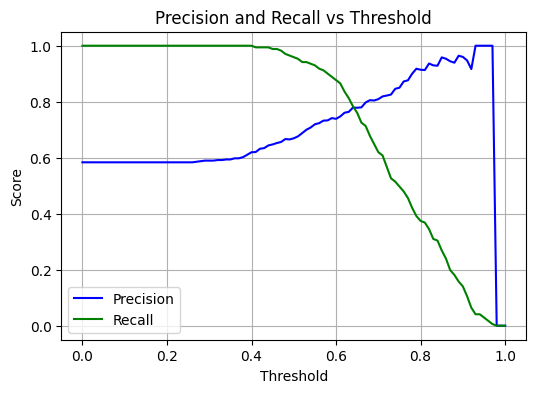

In [14]:
plt.figure(figsize=(6, 4))
plt.plot(thresholds, precisions, label='Precision', color='blue')
plt.plot(thresholds, recalls, label='Recall', color='green')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision and Recall vs Threshold')
plt.legend()
plt.grid(True)
plt.show()


Question 3. Precision and recall

In [15]:
diff = np.abs(np.array(precisions) - np.array(recalls))
t_intersect = thresholds[diff.argmin()]
print(f"Precision and Recall intersect at threshold ≈ {t_intersect:.3f}")

Precision and Recall intersect at threshold ≈ 0.980


Question 4. F1 score

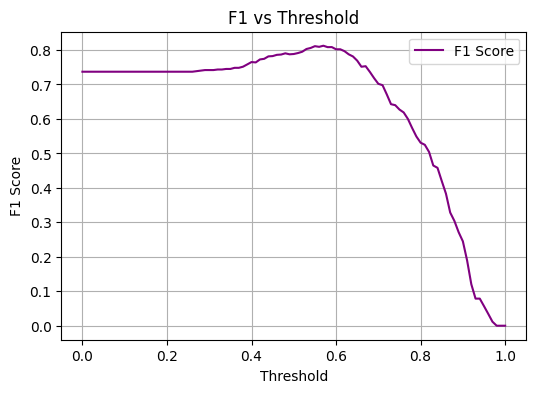

Best Threshold: 0.570, F1 Score: 0.812


In [16]:
thresholds = np.arange(0.0, 1.01, 0.01)
precisions = []
recalls = []
f1_scores = []

for t in thresholds:
    y_pred = (y_pred_proba >= t)
    p = precision_score(y_val, y_pred, zero_division=0)
    r = recall_score(y_val, y_pred)
    precisions.append(p)
    recalls.append(r)
    
    if (p + r) == 0:
        f1_scores.append(0)
    else:
        f1_scores.append(2 * p * r / (p + r))


plt.figure(figsize=(6,4))
plt.plot(thresholds, f1_scores, color='purple', label='F1 Score')
plt.xlabel('Threshold')
plt.ylabel('F1 Score')
plt.title('F1 vs Threshold')
plt.legend()
plt.grid(True)
plt.show()


best_threshold = thresholds[np.argmax(f1_scores)]
best_f1 = np.max(f1_scores)

print(f"Best Threshold: {best_threshold:.3f}, F1 Score: {best_f1:.3f}")

Question 5. 5-Fold CV standard deviation

In [18]:
from sklearn.feature_extraction import DictVectorizer
from sklearn.model_selection import KFold

y_full_train = df_full_train.converted.values
X_full_train = df_full_train.drop('converted', axis=1)

X_full_train_dict = X_full_train.to_dict(orient='records')


kfold = KFold(n_splits=5, shuffle=True, random_state=1)
scores = []

for train_idx, val_idx in kfold.split(X_full_train):
    X_train_dict = [X_full_train_dict[i] for i in train_idx]
    y_train = y_full_train[train_idx]
    
    X_val_dict = [X_full_train_dict[i] for i in val_idx]
    y_val = y_full_train[val_idx]
    
    dv = DictVectorizer(sparse=False)
    X_train_encoded = dv.fit_transform(X_train_dict)
    X_val_encoded = dv.transform(X_val_dict)
    
    model = LogisticRegression(solver='liblinear', C=1.0, max_iter=1000)
    model.fit(X_train_encoded, y_train)
    
    y_pred = model.predict_proba(X_val_encoded)[:, 1]
    auc = roc_auc_score(y_val, y_pred)
    scores.append(auc)

mean_auc = np.mean(scores)
std_auc = np.std(scores)

print("AUC scores per fold:", scores)
print("Mean AUC:", round(mean_auc, 4))
print("Standard Deviation:", round(std_auc, 4))

AUC scores per fold: [0.8060745924216483, 0.8713738368910783, 0.7754320118852139, 0.8018368617683685, 0.8558272713202291]
Mean AUC: 0.8221
Standard Deviation: 0.0358


In [19]:
C_values = [0.000001, 0.001, 1]
kfold = KFold(n_splits=5, shuffle=True, random_state=1)

best_mean = 0
best_std = None
best_C = None

results = []

Question 6: Best C

In [21]:
for C in C_values:
    scores = []
    
    for train_idx, val_idx in kfold.split(X_full_train):
        X_train_dict = [X_full_train_dict[i] for i in train_idx]
        y_train = y_full_train[train_idx]
        
        X_val_dict = [X_full_train_dict[i] for i in val_idx]
        y_val = y_full_train[val_idx]
        
        dv = DictVectorizer(sparse=False)
        X_train_encoded = dv.fit_transform(X_train_dict)
        X_val_encoded = dv.transform(X_val_dict)
        
        model = LogisticRegression(solver='liblinear', C=C, max_iter=1000)
        model.fit(X_train_encoded, y_train)
        
        y_pred = model.predict_proba(X_val_encoded)[:, 1]
        auc = roc_auc_score(y_val, y_pred)
        scores.append(auc)
    
    mean_auc = round(np.mean(scores), 3)
    std_auc = round(np.std(scores), 3)
    
    results.append((C, mean_auc, std_auc))
    print(f"C={C}, mean AUC={mean_auc}, std={std_auc}")
    
    if mean_auc > best_mean or (mean_auc == best_mean and (best_std is None or std_auc < best_std)):
        best_mean = mean_auc
        best_std = std_auc
        best_C = C

        
print(f"\nBest C: {best_C} → mean AUC={best_mean}, std={best_std}")

C=1e-06, mean AUC=0.56, std=0.024
C=0.001, mean AUC=0.867, std=0.029
C=1, mean AUC=0.822, std=0.036

Best C: 0.001 → mean AUC=0.867, std=0.029
